# 01 — Foundation: the data, the labels and the first baselines

This notebook is the guided tour of Prototype 1. It reads the Parquet tables built by the
`bankcanary` CLI (`ingest`, `build-panel`, `build-labels`, `build-features`) and the model
artefacts saved by `bankcanary train`; it never retrains anything, so it runs in well under
two minutes once the data is cached.

## 1. What a Call Report is, and the point-in-time rule

Every FDIC-insured bank files a **Call Report** (Consolidated Reports of Condition and
Income) at the end of each calendar quarter: a balance sheet, an income statement and
supporting schedules on loan quality, capital, funding and concentrations. The FDIC
publishes the data through its BankFind API, which is what `bankcanary ingest` pulls.

A report dated `repdte` is not public on that day. Banks have 30 days to file and the FDIC
publishes the quarter roughly two months after quarter-end, so BankCanary treats every
report as usable only from `avail_date = repdte + 60 days`. The failure label for a
bank-quarter asks: *did the bank fail in the window `(avail_date, avail_date + 12 months]`?*
Failures that happen between `repdte` and `avail_date` are excluded from training (rule
6.2 of the spec) because a model scoring on `avail_date` could never have acted on them.
Everything downstream — the fixed split, the walk-forward backtest of Prototype 2 and the
"time machine" of Prototype 3 — is built on that rule.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "config" / "settings.yaml").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bankcanary.config import load_settings
from bankcanary.models import evaluate_model
from bankcanary.models.train import load_training_frame
from bankcanary.storage.parquet import read_table

settings = load_settings()
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100
print("data_dir:", settings.data_dir)

data_dir: /Users/batuhanisik/Desktop/Projects/bank-failure-early-warning/data


## 2. Failures per year, 2001 onward

The `failures` table is the FDIC failed-bank list. Only `restype == 'FAILURE'` rows count
as failures; open-bank assistance transactions (`ASSISTANCE`) are kept in the table but
never become positives. The picture is the familiar one: a handful of failures a year,
then the 2008-2013 wave, then a long quiet period broken by the 2023 regional-bank
failures.

574 failures from 2001 through 2026


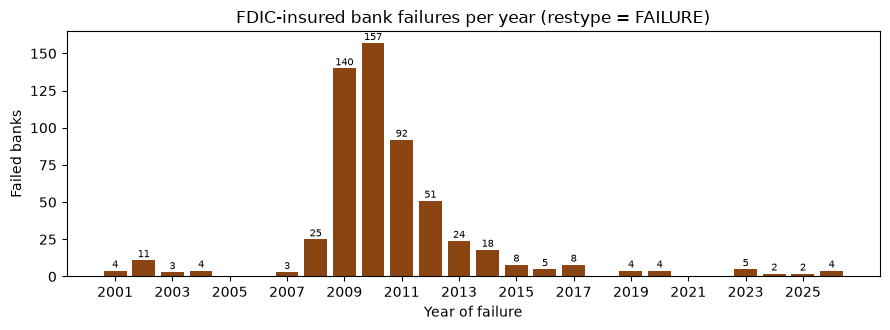

fail_year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
failures,4,11,3,4,0,0,3,25,140,157,...,8,0,4,4,0,0,5,2,2,4


In [2]:
failures = read_table("failures", settings)
failures = failures.loc[failures["restype"].eq("FAILURE") & failures["fail_year"].ge(2001)]
per_year = failures.groupby("fail_year").size().rename("failures")
per_year = per_year.reindex(range(2001, int(failures["fail_year"].max()) + 1), fill_value=0)
print(f"{len(failures)} failures from 2001 through {per_year.index.max()}")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(per_year.index, per_year.to_numpy(), color="#8B4513")
for year, n in per_year.items():
    if n:
        ax.text(year, n + 2, str(n), ha="center", fontsize=7)
ax.set_xlabel("Year of failure")
ax.set_ylabel("Failed banks")
ax.set_title("FDIC-insured bank failures per year (restype = FAILURE)")
ax.set_xticks(per_year.index[::2])
plt.tight_layout()
plt.show()
per_year.to_frame().T

## 3. The panel at a glance

`panel` is one row per bank per quarter-end from 2001Q1 to the latest published quarter,
with the raw Call Report fields plus the availability date and the bank's eventual exit
(failure, merger, voluntary closing). The banking industry has been consolidating for
decades: about 10,000 banks reported in 2001, under 4,500 report today.

710,691 bank-quarters, 11,243 distinct banks, 2001-03-31 to 2026-06-30


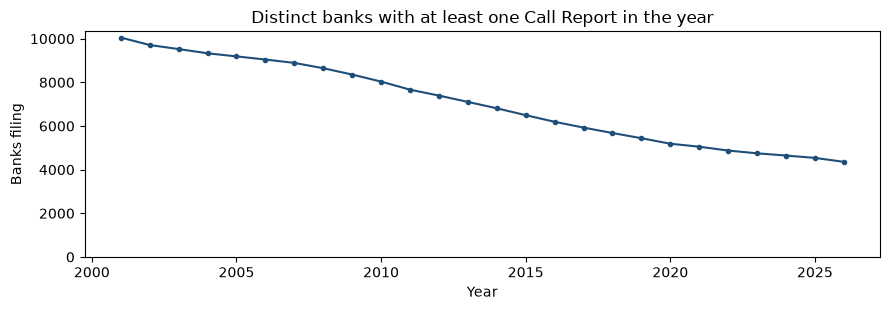

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
rows,39352,38204,37447,36637,35915,35407,34754,34003,32916,31545,...,23325,22301,21366,20478,19942,19285,18798,18399,17893,8666
banks,10054,9712,9526,9333,9190,9047,8892,8649,8359,8035,...,5928,5679,5441,5188,5052,4875,4749,4647,4539,4358


In [3]:
panel = read_table("panel", settings)
by_year = (
    panel.groupby(panel["repdte"].dt.year)
    .agg(rows=("cert", "size"), banks=("cert", "nunique"))
    .rename_axis("year")
)
print(f"{len(panel):,} bank-quarters, {panel['cert'].nunique():,} distinct banks, "
      f"{panel['repdte'].min():%Y-%m-%d} to {panel['repdte'].max():%Y-%m-%d}")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(by_year.index, by_year["banks"], marker="o", markersize=3, color="#1f4e79")
ax.set_ylabel("Banks filing")
ax.set_xlabel("Year")
ax.set_title("Distinct banks with at least one Call Report in the year")
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()
by_year.T

## 4. CAMELS in one paragraph, and what failing banks look like a year out

Bank examiners summarise a bank's health with the **CAMELS** rating: **C**apital adequacy
(equity as a cushion against losses), **A**sset quality (how many loans are not being
repaid), **M**anagement (not observable in the numbers), **E**arnings (whether the bank
makes money), **L**iquidity (whether it can meet withdrawals without fire sales, and how
much of its funding is "hot" wholesale money such as brokered deposits) and **S**ensitivity
to market risk. `features_v1` holds ratios for each observable letter, computed from the
raw fields after de-accumulating year-to-date income items into quarterly flows.

The plots below compare banks that failed within the next four quarters (`y_4q = 1`)
against those that did not, over every bank-quarter whose label window is complete. Boxes show
the quartiles and whiskers the 5th-95th percentiles; axes are clipped to the wider of the two
groups' 5th-95th percentile range so that both boxes stay readable.

692,754 usable bank-quarters, 2,269 fail within 4 quarters (base rate 0.3275%)


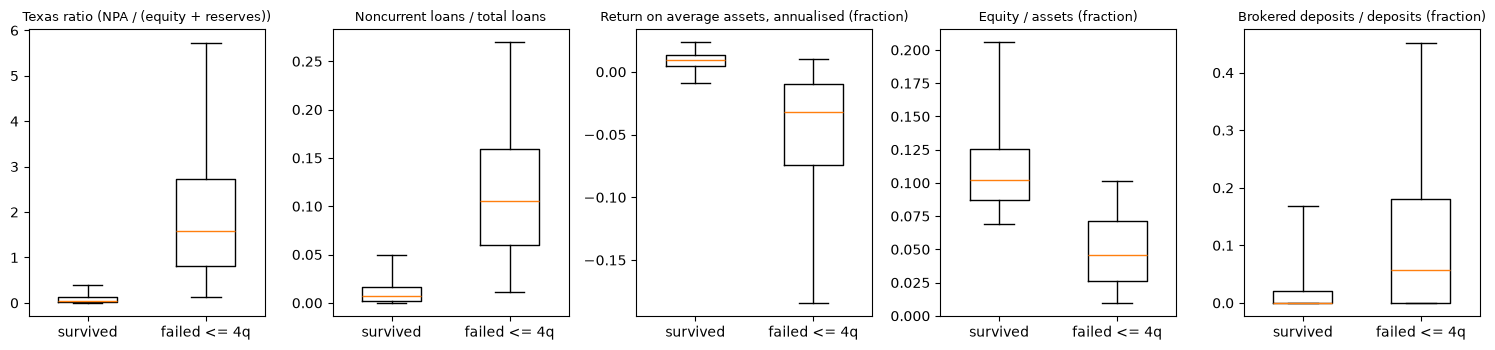

y_4q,failed <= 4q,survived
feature,,
texas_ratio,1.589,0.051
noncurrent_ratio,0.105,0.007
roa_q,-0.032,0.009
equity_to_assets,0.046,0.102
brokered_share,0.057,0.000


In [4]:
frame = load_training_frame(settings)
usable = frame["label_complete_4q"].eq(True) & ~frame["dropped_failed_before_avail"].astype(bool)
usable &= frame["y_4q"].notna()
sample = frame.loc[usable]
y = sample["y_4q"].astype(int)
print(f"{len(sample):,} usable bank-quarters, {int(y.sum()):,} fail within 4 quarters "
      f"(base rate {y.mean():.4%})")

FEATURES = {
    "texas_ratio": "Texas ratio (NPA / (equity + reserves))",
    "noncurrent_ratio": "Noncurrent loans / total loans",
    "roa_q": "Return on average assets, annualised (fraction)",
    "equity_to_assets": "Equity / assets (fraction)",
    "brokered_share": "Brokered deposits / deposits (fraction)",
}
fig, axes = plt.subplots(1, len(FEATURES), figsize=(15, 3.6))
for ax, (col, title) in zip(axes, FEATURES.items()):
    groups = [sample.loc[y.eq(0), col].dropna(), sample.loc[y.eq(1), col].dropna()]
    lo = min(g.quantile(0.05) for g in groups)
    hi = max(g.quantile(0.95) for g in groups)
    pad = 0.05 * (hi - lo)
    ax.boxplot(
        groups, tick_labels=["survived", "failed <= 4q"], showfliers=False, widths=0.5, whis=(5, 95)
    )
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(title, fontsize=9)
plt.tight_layout()
plt.show()

summary = (
    sample.groupby(y.map({0: "survived", 1: "failed <= 4q"}))[list(FEATURES)]
    .median()
    .T.rename_axis("feature")
)
summary.round(3)

Every letter separates the two groups in the expected direction: failing banks carry far
more noncurrent loans relative to their capital (Texas ratio), have lost money over the
quarter (negative ROA), hold thinner equity cushions and lean much more on brokered
deposits. The overlap of the boxes is the reason a single ratio is not enough: many banks
that survived look almost as bad on any one measure.

## 5. Baseline results on the fixed out-of-time split

Three baselines are trained on reports dated 2002Q1-2008Q4 and tested on 2010Q1-2013Q4
(the first test prediction date is 2010-05-30, sixty days after the first test report; the
gap year keeps every training label window closed before the test period starts):

- **texas**: rank banks by the Texas ratio, no fitting at all;
- **logit_small**: logistic regression on six ratios (equity/assets, noncurrent ratio,
  ROA, brokered share, construction loans/capital, log assets);
- **logit**: L2-regularised logistic regression on every Prototype 1 feature, no class
  weighting, with the regularisation strength picked on a validation slice inside the
  training period (`scripts/tune_logit_c.py`).

The cell re-scores the saved pipelines under `models/` on the test rows (about a second)
rather than reading `metrics.json` back, so the artefacts themselves are what is checked.
PR-AUC is the headline metric: with a base rate below one percent, ROC-AUC is near 1 for
any half-sensible ranking and says little about the top of the list, which is where a
supervisor would actually look.

In [5]:
results = evaluate_model(None, 4, settings, frame=frame)
COLS = ["pr_auc", "roc_auc", "recall_at_2pct", "recall_at_top100", "n", "n_failures"]
table = pd.DataFrame({name: r.metrics for name, r in results.items()}).T[COLS]
table.index.name = "model"
table = table.astype({"n": int, "n_failures": int})
table.round(4)

,pr_auc,roc_auc,recall_at_2pct,recall_at_top100,n,n_failures
model,,,,,,
texas,0.3726,0.9739,0.7611,0.0720,118696,833
logit_small,0.3720,0.9791,0.7383,0.0792,118696,833
logit,0.3867,0.9755,0.7143,0.0804,118696,833


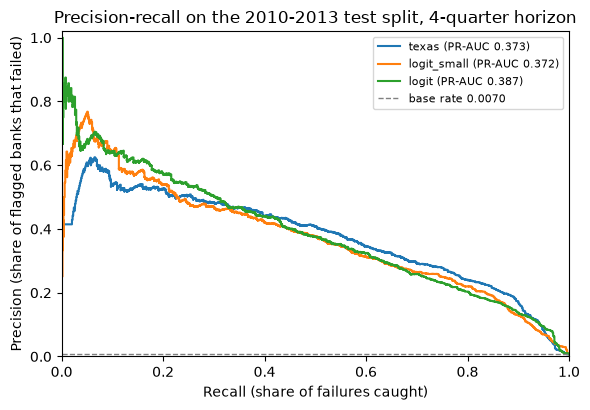

In [6]:
from sklearn.metrics import precision_recall_curve

base_rate = results["texas"].scores["y"].mean()
fig, ax = plt.subplots(figsize=(6, 4.2))
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(r.scores["y"], r.scores["score"])
    ax.step(rec, prec, where="post", label=f"{name} (PR-AUC {r.metrics['pr_auc']:.3f})")
ax.axhline(base_rate, linestyle="--", linewidth=1, color="grey", label=f"base rate {base_rate:.4f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall (share of failures caught)")
ax.set_ylabel("Precision (share of flagged banks that failed)")
ax.set_title("Precision-recall on the 2010-2013 test split, 4-quarter horizon")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 6. The Texas ratio, and why the logistic models do (not) beat it

The **Texas ratio** is nonperforming assets (noncurrent loans plus foreclosed real estate)
divided by tangible equity plus loan-loss reserves. It was coined during the 1980s Texas
banking bust as a rule of thumb: once problem assets exceed the capital available to
absorb them (ratio above 1), the bank is usually beyond saving. It is a single number that
already combines the two letters that matter most in a credit-driven crisis, Asset quality
and Capital, which is why it is such a strong baseline for the 2008-2013 wave.

The results are honest rather than flattering. The six-feature logistic regression matches
the Texas ratio on PR-AUC (0.372 vs 0.373) and beats it on ROC-AUC and recall in the top 100,
but it does not clearly beat it. The all-feature `logit` edges ahead (PR-AUC 0.387), and
only after a lesson: with balanced class weights the same model scored 0.199, because
weighting 554 training failures up by a factor of 450 let a handful of failed banks push
its four collinear capital measures to large, sign-flipped coefficients. Dropping the class
weights and choosing the L2 strength on a validation slice carved from the training years
(never the test years; see `docs/DECISIONS.md`) fixes that, which is what the acceptance
criterion "regularised logit beats the Texas ratio on PR-AUC" now rests on. The report
also shows the same numbers with censored rows dropped and per failure event.

In [7]:
# Per-year view of the best baseline: 2010 carries half the test failures.
by_year = pd.DataFrame(results["logit_small"].by_year).set_index("year")
by_year[["n", "n_failures", "pr_auc", "roc_auc", "recall_at_2pct", "recall_at_top100"]].round(4)

,n,n_failures,pr_auc,roc_auc,recall_at_2pct,recall_at_top100
year,,,,,,
2010,31431,408,0.4153,0.9717,0.5980,0.1593
2011,30165,231,0.3773,0.9823,0.6667,0.2251
2012,29130,121,0.3585,0.9877,0.8099,0.3554
2013,27970,73,0.1721,0.9712,0.6849,0.2466
pooled,118696,833,0.3720,0.9791,0.7383,0.0792


## 7. Next steps for Prototype 2

1. **Walk-forward backtest** instead of one fixed split: train on everything up to year
   *t*, predict year *t + 1*, repeat from 2006 onward, so the model is judged on every
   crisis year and on the quiet years after it.
2. **Feature selection and a gradient-boosting model** (LightGBM) with monotone
   constraints, plus a discrete-time hazard model; the collinear capital block that
   nearly sank the all-feature logit needs pruning or a tree model that does not care.
3. **Interest-rate and funding features** (securities duration, unrealised losses,
   uninsured-deposit share) so the model can see a 2023-style run, which the credit-quality
   features above cannot.
4. **Calibration and lead time**: probabilities that mean what they say, and how many
   quarters before failure a bank first enters the top 2%.
5. **Explanations** per prediction (coefficients and SHAP values) and peer comparisons by
   asset bucket, which the dashboard of Prototype 3 will show.